# Neural Rendering

## Data Preperation


In [1]:
import os
import json
import random
from typing import Optional, Tuple, List, Dict, Literal

import torch
from torch import Tensor
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torchvision.transforms import Compose

SplitType = Literal["train", "val", "test"]

class PhongDataset(Dataset[Tuple[Tensor, Tensor]]):
    def __init__(
        self,
        base_path: str,
        split: SplitType = "train",
        split_ratio: Tuple[float, float, float] = (0.8, 0.1, 0.1),
        transform: Optional[Compose] = None,
        cache_images: bool = False,
        seed: int = 42,
    ) -> None:
        self.image_path = os.path.join(base_path, "images")
        self.json_path = os.path.join(base_path, "dataset.json")
        self.transform = transform or transforms.ToTensor()
        self.cache_images = cache_images

        with open(self.json_path, "r") as f:
            all_samples: List[Dict] = json.load(f)

        random.seed(seed)
        random.shuffle(all_samples)
        total = len(all_samples)
        train_end = int(total * split_ratio[0])
        val_end = train_end + int(total * split_ratio[1])

        if split == "train":
            self.samples = all_samples[:train_end]
        elif split == "val":
            self.samples = all_samples[train_end:val_end]
        elif split == "test":
            self.samples = all_samples[val_end:]
        else:
            raise ValueError(f"Invalid split: {split}")

        self.image_cache: Dict[str, Tensor] = {}
        if self.cache_images:
            print(f"Caching {len(self.samples)} images in memory for split '{split}'...")
            for entry in self.samples:
                image_path = os.path.join(self.image_path, entry["image_filename"])
                img = Image.open(image_path).convert("RGB")
                self.image_cache[entry["image_filename"]] = self.transform(img)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[Tensor, Tensor]:
        entry = self.samples[idx]
        input_vec: List[float] = (
            entry["model_translation_relative"] +
            entry["material_diffuse"] +
            [entry["material_shininess"]] +
            entry["light_position"]
        )
        input_tensor: Tensor = torch.tensor(input_vec, dtype=torch.float32)

        if self.cache_images:
            target_tensor = self.image_cache[entry["image_filename"]]
        else:
            image = Image.open(os.path.join(self.image_path, entry["image_filename"])).convert("RGB")
            target_tensor = self.transform(image)

        return input_tensor, target_tensor

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
%env BASE_DATA_PATH=/content/drive/MyDrive/data/phong/v5

env: BASE_DATA_PATH=/content/drive/MyDrive/data/phong/v5


In [26]:
from torch.utils.data import DataLoader

base_path = os.getenv("BASE_DATA_PATH")

train_set = PhongDataset(base_path, split="train", cache_images=True)
val_set = PhongDataset(base_path, split="val", cache_images=True)
test_set = PhongDataset(base_path, split="test", cache_images=False)

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

for inputs, images in test_loader:
    print("Input shape:", inputs.shape)
    print("Output shape:", images.shape)
    break

Caching 1600 images in memory for split 'train'...
Caching 200 images in memory for split 'val'...
Input shape: torch.Size([32, 10])
Output shape: torch.Size([32, 3, 128, 128])


## Model Architectures

In [27]:
import torch
import torch.nn as nn

class PhongMLPGenerator(nn.Module):
    def __init__(self, input_dim: int = 10, output_shape: tuple = (3, 128, 128)):
        super().__init__()
        self.output_shape = output_shape
        self.latent_size = 8  # rozmiar startowy HxW

        # Z wektora wejściowego → tensor 256×8×8
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256 * self.latent_size * self.latent_size),
            nn.ReLU()
        )

        # Upsample: 256→128→64→32→3 kanały
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()  # obraz RGB w [0, 1]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc(x)
        x = x.view(-1, 256, self.latent_size, self.latent_size)
        return self.upsample(x)


In [28]:
model = PhongMLPGenerator(input_dim=10, output_shape=(3, 128, 128))
for inputs, images in train_loader:
    print("Input shape:", inputs.shape)
    print("Output shape:", images.shape)

    output = model(inputs)
    print("Model output shape:", output.shape)
    break

Input shape: torch.Size([32, 10])
Output shape: torch.Size([32, 3, 128, 128])
Model output shape: torch.Size([32, 3, 128, 128])


## Training

### Experiment tracking setup

In [29]:
! pip install -q neptune

In [30]:
import neptune

In [31]:
NEPTUNE_PROJECT_NAME = "sigk/neural-rendering"
NEPTUNE_API_KEY = input("Enter Neptune API key: ")

Enter Neptune API key: eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI4ODA4YThkMy04N2Y5LTQ4NzItYmExMi1hNDdkM2Y4ZTJiNWYifQ==


### Training loop

In [32]:
! pip install -q flip-evaluator

In [33]:
import os
import flip_evaluator as flip
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image

def train_phong_generator(
    model: nn.Module,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 10,
    run: neptune.Run | None = None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            if run:
                run["train/step/loss"].append(loss.item())

        avg_train_loss = total_loss / len(train_loader)

        if run:
          run["train/epoch/loss"].append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        val_flip = 0.0
        with torch.no_grad():
            for val_inputs, val_targets in val_loader:
                val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)
                val_outputs = model(val_inputs)

                loss = criterion(val_outputs, val_targets)
                val_loss += loss.item()
                if run:
                    run["val/step/loss"].append(loss.item())

                for i in range(val_outputs.size(0)):
                    pred = val_outputs[i].cpu().permute(1, 2, 0).numpy()
                    ref = val_targets[i].cpu().permute(1, 2, 0).numpy()
                    flip_error_map, mean_flip_error, parameters = flip.evaluate(ref, pred, "LDR")
                    val_flip += mean_flip_error

                    if run:
                        run["val/step/flip"].append(mean_flip_error)

        avg_val_loss = val_loss / len(val_loader)
        avg_flip = val_flip / (len(val_loader.dataset))

        if run:
            run["val/epoch/loss"].append(avg_val_loss)
            run["val/epoch/flip"].append(avg_flip)

        print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | FLIP: {avg_flip:.4f}")


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PhongMLPGenerator()
model = model.to(device)
criterion = nn.MSELoss()
lr: float = 1e-4
optimizer = optim.Adam(model.parameters(), lr=lr)
epochs=5

In [36]:
run = neptune.init_run(
    project=NEPTUNE_PROJECT_NAME,
    api_token=NEPTUNE_API_KEY,
)
params = {
    "model_name": model.__class__.__name__,
    "optimizer_name": optimizer.__class__.__name__,
    "loss_function": "MSELoss+PerceptualLoss",
    "learning_rate": lr,
    "epochs": epochs,
    "dataset_size": len(train_set),
    "batch_size": 32,
}
run["parameters"] = params

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/sigk/neural-rendering/e/NEUR-5


In [37]:
train_phong_generator(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    num_epochs=epochs,
    run=run,
)

[Epoch 1] Train Loss: 0.0380 | Val Loss: 0.0051 | FLIP: 0.0283
[Epoch 2] Train Loss: 0.0052 | Val Loss: 0.0051 | FLIP: 0.0277
[Epoch 3] Train Loss: 0.0052 | Val Loss: 0.0051 | FLIP: 0.0276
[Epoch 4] Train Loss: 0.0052 | Val Loss: 0.0051 | FLIP: 0.0275
[Epoch 5] Train Loss: 0.0052 | Val Loss: 0.0051 | FLIP: 0.0274


In [38]:
def test_model(
    model: nn.Module,
    test_loader: DataLoader,
    run: neptune.Run | None = None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    model.eval()
    test_flip = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            for i in range(outputs.size(0)):
                pred = outputs[i].cpu().permute(1, 2, 0).numpy()
                ref = targets[i].cpu().permute(1, 2, 0).numpy()
                flip_error_map, mean_flip_error, parameters = flip.evaluate(ref, pred, "LDR")
                test_flip += mean_flip_error

                if run:
                    run["test/step/flip"].append(mean_flip_error)

    avg_flip = test_flip / (len(val_loader.dataset))
    if run:
        run["test/flip"].append(avg_flip)
    print(f"FLIP: {avg_flip:.4f}")


In [39]:
test_model(model, test_loader, run=run)

FLIP: 0.0281


In [40]:
import matplotlib.pyplot as plt
import torch

def plot_predictions(
    model: torch.nn.Module,
    test_loader: torch.utils.data.DataLoader,
    n: int = 5,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    model.eval()
    fig, axes = plt.subplots(n, 2, figsize=(10, 2 * n))  # n par na wykresie

    with torch.no_grad():
        for i, (inputs, targets) in enumerate(test_loader):
            if i >= n:
                break

            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            # Rysowanie pary GT i predykcji
            ax_gt, ax_pred = axes[i]
            ax_gt.imshow(targets[0].cpu().permute(1, 2, 0).numpy())
            ax_gt.set_title(f"Ground Truth {i+1}")
            ax_gt.axis('off')

            ax_pred.imshow(outputs[0].cpu().permute(1, 2, 0).numpy())
            ax_pred.set_title(f"Prediction {i+1}")
            ax_pred.axis('off')

    plt.tight_layout()
    plt.show()

    return fig


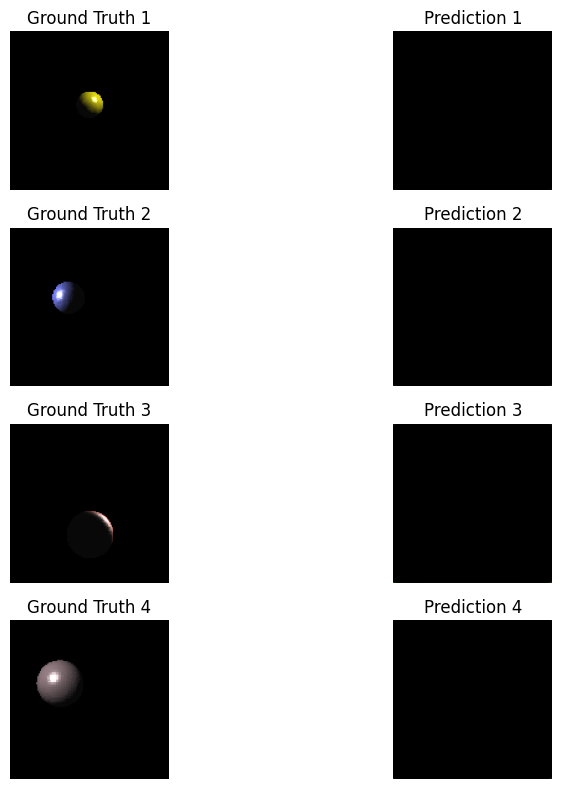

In [45]:
fig = plot_predictions(model, test_loader, n=4)

In [46]:
run["test/sample"].upload(fig)

In [47]:
run.stop()

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 1 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 1 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/sigk/neural-rendering/e/NEUR-5/metadata
